## Data Collection

This project utilizes the **Delayed Flights Dataset** obtained from Kaggle. The dataset contains detailed information on commercial flight operations, including departure and arrival schedules, delays, cancellations, flight routes, carrier information, and various causes of flight delays.

**Source**: [Kaggle](https://www.kaggle.com/datasets/abdurrehmankhalid/delayedflights).

## Project Objective
This project analyses 1.9M+ commercial flight records to identify 
key delay patterns across airlines, airports, and seasons - and 
determine the primary causes of delays using Python and PostgreSQL.

### Dataset Overview

| Metric | Value |
|----------|----------|
| Total Records | 1,936,758 |
| Total Features | 30 |
| Domain | Aviation & Flight Operations Analytics |

The dataset provides comprehensive flight performance data across multiple airlines and airports. It enables the analysis of flight punctuality, delay patterns, cancellation trends, airline performance, and the impact of operational factors such as weather, security, air traffic congestion, and late aircraft arrivals.

### Key Information Captured
- Flight Schedule Information (Departure & Arrival Times)
- Airline and Flight Details
- Origin and Destination Airports
- Flight Distance and Air Time
- Departure and Arrival Delays
- Flight Cancellations and Diversions
- Delay Causes:
  - Carrier Delay
  - Weather Delay
  - NAS (National Airspace System) Delay
  - Security Delay
  - Late Aircraft Delay

In [1]:
# loading and inspecting the dataset
import pandas as pd
df = pd.read_csv('../datasets_of_res_projects/DelayedFlights.csv')
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1936758 entries, 0 to 1936757
Data columns (total 30 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Unnamed: 0         int64  
 1   Year               int64  
 2   Month              int64  
 3   DayofMonth         int64  
 4   DayOfWeek          int64  
 5   DepTime            float64
 6   CRSDepTime         int64  
 7   ArrTime            float64
 8   CRSArrTime         int64  
 9   UniqueCarrier      object 
 10  FlightNum          int64  
 11  TailNum            object 
 12  ActualElapsedTime  float64
 13  CRSElapsedTime     float64
 14  AirTime            float64
 15  ArrDelay           float64
 16  DepDelay           float64
 17  Origin             object 
 18  Dest               object 
 19  Distance           int64  
 20  TaxiIn             float64
 21  TaxiOut            float64
 22  Cancelled          int64  
 23  CancellationCode   object 
 24  Diverted           int64  
 25  CarrierDelay      

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,0,2008,1,3,4,2003.0,1955,2211.0,2225,WN,...,4.0,8.0,0,N,0,NaN,NaN,NaN,NaN,NaN
1,1,2008,1,3,4,754.0,735,1002.0,1000,WN,...,5.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN
2,2,2008,1,3,4,628.0,620,804.0,750,WN,...,3.0,17.0,0,N,0,NaN,NaN,NaN,NaN,NaN
3,4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,...,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
4,5,2008,1,3,4,1940.0,1915,2121.0,2110,WN,...,4.0,10.0,0,N,0,NaN,NaN,NaN,NaN,NaN


In [2]:
df.shape

(1936758, 30)

## Data Cleaning

In [3]:
# Checking the number of NaNs in every column
print(df.isna().sum())

Unnamed: 0                0
Year                      0
Month                     0
DayofMonth                0
DayOfWeek                 0
DepTime                   0
CRSDepTime                0
ArrTime                7110
CRSArrTime                0
UniqueCarrier             0
FlightNum                 0
TailNum                   5
ActualElapsedTime      8387
CRSElapsedTime          198
AirTime                8387
ArrDelay               8387
DepDelay                  0
Origin                    0
Dest                      0
Distance                  0
TaxiIn                 7110
TaxiOut                 455
Cancelled                 0
CancellationCode          0
Diverted                  0
CarrierDelay         689270
WeatherDelay         689270
NASDelay             689270
SecurityDelay        689270
LateAircraftDelay    689270
dtype: int64


In [4]:
df = df.dropna(subset = ['ArrTime', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'TaxiIn', 'TaxiOut', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay'])

In [5]:
df.shape

(1247488, 30)

In [6]:
print(df.isna().sum())

Unnamed: 0           0
Year                 0
Month                0
DayofMonth           0
DayOfWeek            0
DepTime              0
CRSDepTime           0
ArrTime              0
CRSArrTime           0
UniqueCarrier        0
FlightNum            0
TailNum              2
ActualElapsedTime    0
CRSElapsedTime       0
AirTime              0
ArrDelay             0
DepDelay             0
Origin               0
Dest                 0
Distance             0
TaxiIn               0
TaxiOut              0
Cancelled            0
CancellationCode     0
Diverted             0
CarrierDelay         0
WeatherDelay         0
NASDelay             0
SecurityDelay        0
LateAircraftDelay    0
dtype: int64


In [7]:
df.head()

,Unnamed: 0,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,...,TaxiIn,TaxiOut,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
3,4,2008,1,3,4,1829.0,1755,1959.0,1925,WN,...,3.0,10.0,0,N,0,2.0,0.0,0.0,0.0,32.0
5,6,2008,1,3,4,1937.0,1830,2037.0,1940,WN,...,3.0,7.0,0,N,0,10.0,0.0,0.0,0.0,47.0
7,11,2008,1,3,4,1644.0,1510,1845.0,1725,WN,...,6.0,8.0,0,N,0,8.0,0.0,0.0,0.0,72.0
9,16,2008,1,3,4,1452.0,1425,1640.0,1625,WN,...,7.0,8.0,0,N,0,3.0,0.0,0.0,0.0,12.0
11,18,2008,1,3,4,1323.0,1255,1526.0,1510,WN,...,4.0,9.0,0,N,0,0.0,0.0,0.0,0.0,16.0


In [8]:
# checking for duplicate rows in the dataset
print(df.duplicated().sum())

0


In [9]:
# Removing the columns which are not required
df = df.drop(columns = ['TailNum', 'Unnamed: 0'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1247488 entries, 3 to 1936755
Data columns (total 28 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Year               1247488 non-null  int64  
 1   Month              1247488 non-null  int64  
 2   DayofMonth         1247488 non-null  int64  
 3   DayOfWeek          1247488 non-null  int64  
 4   DepTime            1247488 non-null  float64
 5   CRSDepTime         1247488 non-null  int64  
 6   ArrTime            1247488 non-null  float64
 7   CRSArrTime         1247488 non-null  int64  
 8   UniqueCarrier      1247488 non-null  object 
 9   FlightNum          1247488 non-null  int64  
 10  ActualElapsedTime  1247488 non-null  float64
 11  CRSElapsedTime     1247488 non-null  float64
 12  AirTime            1247488 non-null  float64
 13  ArrDelay           1247488 non-null  float64
 14  DepDelay           1247488 non-null  float64
 15  Origin             1247488 non-null  

In [11]:
# Correcting the Datatypes of DepTime and ArrTime and extracting the hours.
df['DepTime'] = df['DepTime'].astype(int)
df['DepHour'] = df['DepTime'] // 100

df['ArrTime'] = df['ArrTime'].astype(int)
df['ArrHour'] = df['ArrTime'] // 100

In [12]:
df.head()

,Year,Month,DayofMonth,DayOfWeek,DepTime,CRSDepTime,ArrTime,CRSArrTime,UniqueCarrier,FlightNum,...,Cancelled,CancellationCode,Diverted,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,DepHour,ArrHour
3,2008,1,3,4,1829,1755,1959,1925,WN,3920,...,0,N,0,2.0,0.0,0.0,0.0,32.0,18,19
5,2008,1,3,4,1937,1830,2037,1940,WN,509,...,0,N,0,10.0,0.0,0.0,0.0,47.0,19,20
7,2008,1,3,4,1644,1510,1845,1725,WN,1333,...,0,N,0,8.0,0.0,0.0,0.0,72.0,16,18
9,2008,1,3,4,1452,1425,1640,1625,WN,675,...,0,N,0,3.0,0.0,0.0,0.0,12.0,14,16
11,2008,1,3,4,1323,1255,1526,1510,WN,4,...,0,N,0,0.0,0.0,0.0,0.0,16.0,13,15


In [13]:
# Cancellation code standardization
print(df['CancellationCode'].unique())

['N']


In [14]:
# Checking if any of the flight got cancelled and diverted
print(df['Diverted'].unique())

[0]


In [15]:
print(df['Cancelled'].unique())

[0]


In [16]:
# removing extra spaces from categorical columns
df['UniqueCarrier'] = df['UniqueCarrier'].str.strip()
df['Origin'] = df['Origin'].str.strip()
df['Dest'] = df['Dest'].str.strip()

In [17]:
# Checking for outliers in numeric columns
df[['ArrDelay', 'DepDelay']].describe()

,ArrDelay,DepDelay
count,1.247488e+06,1.247488e+06
mean,6.329121e+01,5.967735e+01
std,6.075410e+01,5.986909e+01
min,1.500000e+01,6.000000e+00
25%,2.600000e+01,2.400000e+01
50%,4.300000e+01,4.100000e+01
75%,7.900000e+01,7.500000e+01
max,2.461000e+03,2.467000e+03


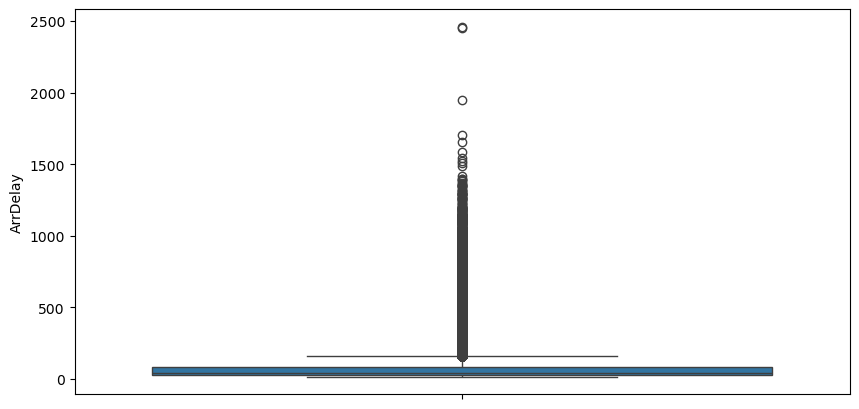

In [18]:
# Plotting Boxplot to check outliers in ArrDelay
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize = (10,5))
sns.boxplot(df['ArrDelay'])
plt.show()

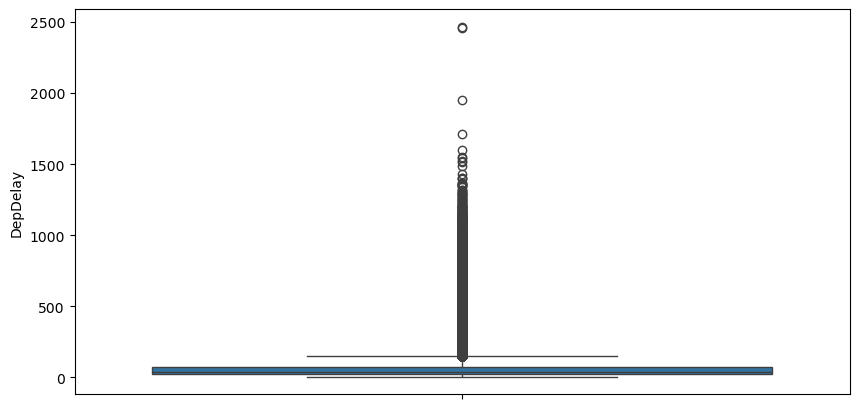

In [19]:
# Plotting Boxplot to check outliers in DepDelay
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize = (10,5))
sns.boxplot(df['DepDelay'])
plt.show()

In [20]:
# Storing the dataframe 
original_df = df

In [21]:
# IQR method for filtering out the outliers in Arrival delay
# ArrDelay bounds
arr_q1 = df['ArrDelay'].quantile(0.25)
arr_q3 = df['ArrDelay'].quantile(0.75)
arr_iqr = arr_q3 - arr_q1

arr_lower = arr_q1 - 1.5 * arr_iqr
arr_upper = arr_q3 + 1.5 * arr_iqr

# DepDelay bounds
dep_q1 = df['DepDelay'].quantile(0.25)
dep_q3 = df['DepDelay'].quantile(0.75)
dep_iqr = dep_q3 - dep_q1

dep_lower = dep_q1 - 1.5 * dep_iqr
dep_upper = dep_q3 + 1.5 * dep_iqr

# Apply both conditions together
filtered_df = df[
    (df['ArrDelay'] >= arr_lower) &
    (df['ArrDelay'] <= arr_upper) &
    (df['DepDelay'] >= dep_lower) &
    (df['DepDelay'] <= dep_upper)
].copy()

In [22]:
filtered_df.shape

(1153046, 30)

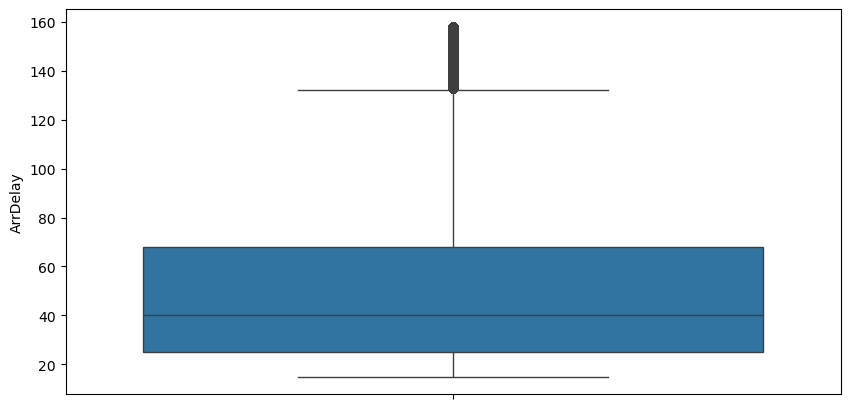

In [23]:
# Checking again for the extreme outliers in ArrDelay
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize = (10,5))
sns.boxplot(filtered_df['ArrDelay'])
plt.show()

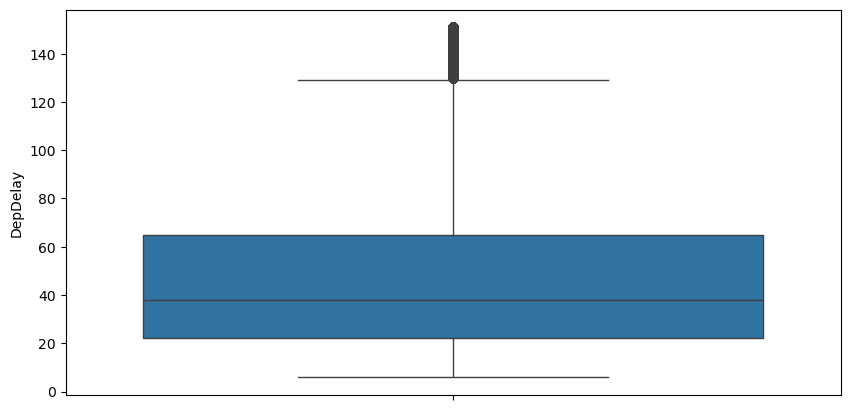

In [24]:
import matplotlib.pyplot as plt 
import seaborn as sns

plt.figure(figsize = (10,5))
sns.boxplot(filtered_df['DepDelay'])
plt.show()

In [25]:
print(filtered_df['ArrDelay'].min())
print(filtered_df['ArrDelay'].max())

print(filtered_df['DepDelay'].min())
print(filtered_df['DepDelay'].max())

15.0
158.0
6.0
151.0


In [26]:
# saving the datasets
original_df.to_csv("original_airlines_delay_cleaned_dataset.csv",index = False)
filtered_df.to_csv("filtered_airlines_delay_cleaned_dataset.csv",index = False)

### EDA (Exploratory Data Analysis)

In [27]:
# Airline wise average arrival and departure delay 
airline_delay = filtered_df.groupby('UniqueCarrier')[['ArrDelay', 'DepDelay']].mean().reset_index()
print(airline_delay)

   UniqueCarrier   ArrDelay   DepDelay
0             9E  52.483506  49.443102
1             AA  52.677285  48.719694
2             AQ  37.506061  37.575758
3             AS  46.282103  43.529297
4             B6  56.851458  51.958194
5             CO  51.769864  48.175929
6             DL  48.211889  41.986700
7             EV  52.136722  49.852411
8             F9  39.851713  34.829451
9             FL  50.080720  44.887015
10            HA  38.344819  34.605218
11            MQ  51.550995  46.677182
12            NW  47.845939  40.798386
13            OH  53.265463  47.858848
14            OO  53.148318  49.640825
15            UA  54.324290  52.518710
16            US  48.207890  45.212601
17            WN  44.659497  45.705759
18            XE  53.492461  50.181155
19            YV  54.329887  52.484987


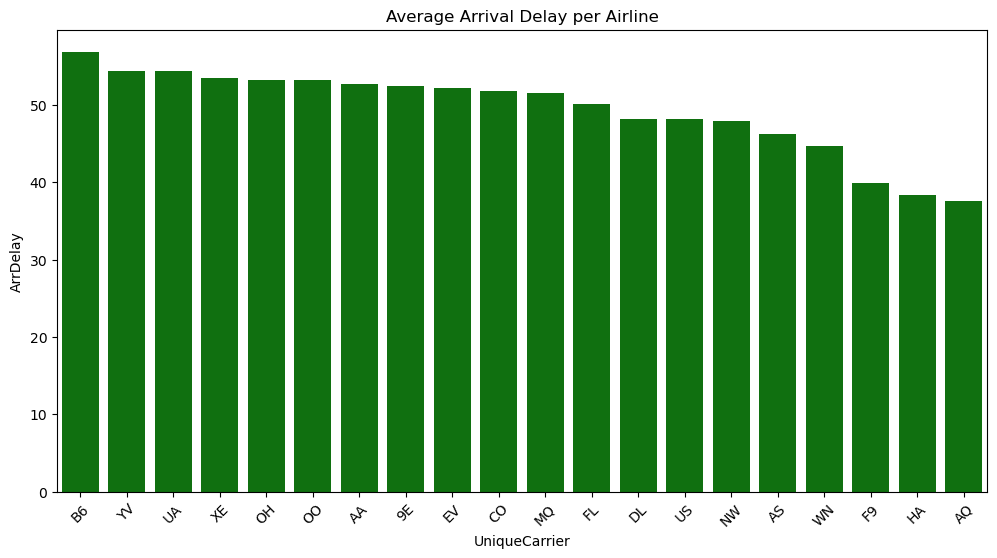

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Airline-wise avg ArrDelay
plt.figure(figsize=(12,6))
sns.barplot(
    data=airline_delay.sort_values('ArrDelay', ascending=False),
    x='UniqueCarrier',
    y='ArrDelay',
    color='g'
)
plt.title("Average Arrival Delay per Airline")
plt.xticks(rotation=45)
plt.show()

## Key Insight — Airline Delay Rankings
- **B6 (JetBlue)** has the highest avg arrival delay at ~57 mins
- **AQ (Aloha Air)** performs best at ~37.5 mins
- Top 5 worst airlines account for disproportionate delays
- Departure delays closely mirror arrival delays across carriers

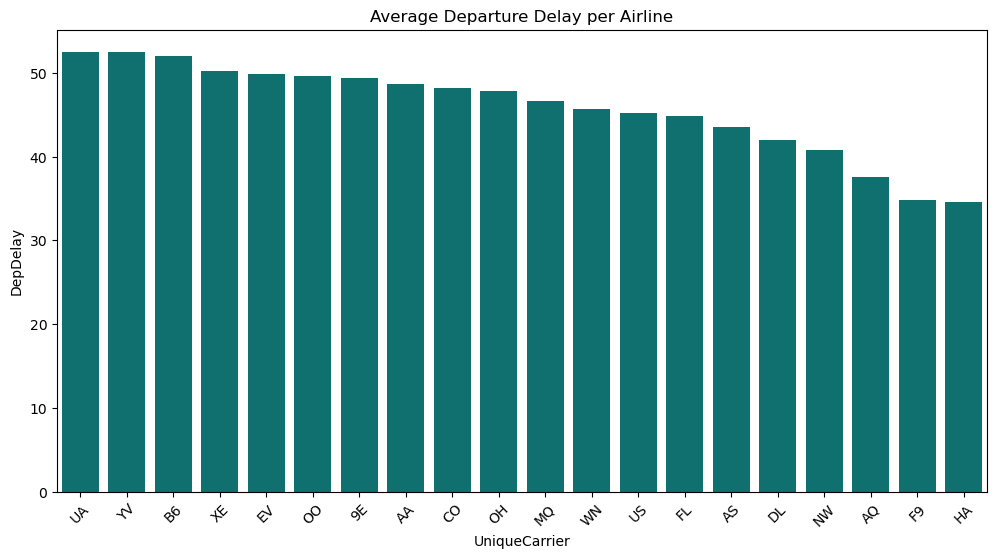

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Airline-wise avg DepDelay
plt.figure(figsize=(12,6))
sns.barplot(data=airline_delay.sort_values('DepDelay', ascending = False),
                                           x='UniqueCarrier',
                                           y='DepDelay',
                                           color ='teal'
                                          )
plt.title("Average Departure Delay per Airline")
plt.xticks(rotation=45)
plt.show()

## Key Insight — Airline Delay Rankings

**Arrival Delay:**
- **B6 (JetBlue Airways)** has the highest avg arrival delay at ~57 mins
- **AQ (Aloha Air)** performs best at ~37.5 mins

**Departure Delay:**
- **UA (United Airlines)**, **YV**, and **B6** lead with ~52 mins departure delay
- **HA (Hawaiian Airlines)** and **AQ** are the most punctual at ~34–35 mins

**Key Takeaway:** Departure and arrival delay rankings closely mirror each other,
suggesting that airlines that depart late also arrive late — 
pointing to systemic operational inefficiencies rather than in-flight recovery.

In [30]:
# Month wise Delay pattern
month_delay = filtered_df.groupby('Month')[['ArrDelay', 'DepDelay']].mean().reset_index()
print(month_delay)

    Month   ArrDelay   DepDelay
0       1  50.524046  47.253642
1       2  51.667025  47.740801
2       3  49.957683  46.870073
3       4  48.246072  44.927487
4       5  47.919228  44.982789
5       6  52.559472  48.267726
6       7  51.942080  49.355636
7       8  50.095011  48.573826
8       9  48.093222  46.755566
9      10  45.595633  44.345315
10     11  50.360845  47.664492
11     12  52.916502  48.746196


In [31]:
# Sorting monthly arrival and departure delays
import calendar

month_delay['Month_Name'] = month_delay['Month'].apply(
    lambda x: calendar.month_name[x]
)

print(
    month_delay[['Month_Name', 'ArrDelay']]
    .sort_values('ArrDelay', ascending=False)
)

   Month_Name   ArrDelay
11   December  52.916502
5        June  52.559472
6        July  51.942080
1    February  51.667025
0     January  50.524046
10   November  50.360845
7      August  50.095011
2       March  49.957683
3       April  48.246072
8   September  48.093222
4         May  47.919228
9     October  45.595633


In [32]:
print(
    month_delay[['Month_Name', 'DepDelay']]
    .sort_values('DepDelay', ascending=False)
)

   Month_Name   DepDelay
6        July  49.355636
11   December  48.746196
7      August  48.573826
5        June  48.267726
1    February  47.740801
10   November  47.664492
0     January  47.253642
2       March  46.870073
8   September  46.755566
4         May  44.982789
3       April  44.927487
9     October  44.345315


In [33]:
# December month has a maximum avg of arrival delay i.e., ~53 mins.
# october month has a minimum avg of arrival delay i.e., ~46 mins.
# july month has a maximum avg of departure delay i.e., ~50 mins.
# october month has a minimum of avg departure delay i.e., ~44.4 mins.

In [34]:
# Origin vs destination-wise delay
origin_delay = filtered_df.groupby('Origin')[['ArrDelay', 'DepDelay']].mean().reset_index()
dest_delay = filtered_df.groupby('Dest')[['ArrDelay', 'DepDelay']].mean().reset_index()

In [35]:
print(origin_delay[['Origin','ArrDelay']].sort_values('ArrDelay', ascending = False))

    Origin    ArrDelay
223    PIR  118.000000
272    SPI   74.037500
232    PUB   74.000000
32     BJI   71.333333
38     BPT   71.181818
..     ...         ...
145    ITO   39.182561
239    RFD   38.454545
83     DLG   36.709091
300    YKM   34.322581
141    INL   15.000000

[302 rows x 2 columns]


In [36]:
# PIR (Pierre Regional Airport) has the maximum Arrival delay of ~118 mins.
# INL (Falls International Airport) has the minimum Arrival delay of ~15 mins.

In [37]:
print(origin_delay[['Origin','DepDelay']].sort_values('DepDelay', ascending = False))

    Origin   DepDelay
223    PIR  99.000000
38     BPT  70.272727
272    SPI  69.529167
7      ACY  68.571429
236    RDD  66.920548
..     ...        ...
242    RKS  31.569444
239    RFD  30.863636
300    YKM  27.838710
232    PUB  27.000000
141    INL  23.000000

[302 rows x 2 columns]


In [38]:
# PIR (Pierre Regional Airport) has the maximum Departure delay of ~99 mins.
# INL (Falls International Airport) has the minimum Departure delay of ~23 mins.

In [39]:
print(dest_delay[['Dest','ArrDelay']].sort_values('ArrDelay', ascending = False))

    Dest   ArrDelay
4    ACK  64.175439
195  MQT  63.518900
281  TEX  62.652174
58   CIC  62.257732
32   BJI  62.250000
..   ...        ...
33   BLI  38.428571
142  IPL  38.410526
145  ITO  36.232624
146  IYK  34.684211
223  PIR  31.000000

[301 rows x 2 columns]


In [40]:
# ACK (Nantucket Memorial Airport) has the maximum Arrival delay of ~65 mins.
# PIR (Pierre Regional Airport) has the minimum Arrival delay of ~31 mins.

In [41]:
print(dest_delay[['Dest','DepDelay']].sort_values('DepDelay', ascending = False))

    Dest   DepDelay
32   BJI  70.750000
166  LMT  61.700855
58   CIC  61.628866
195  MQT  61.436426
176  MCN  61.428571
..   ...        ...
144  ITH  35.384615
146  IYK  35.245614
145  ITO  32.303546
299  YKM  31.703704
223  PIR  29.000000

[301 rows x 2 columns]


In [42]:
# BJI (Bemidji Regional Airport) has the maximum Departure delay of ~71 mins.
# PIR (Pierre Regional Airport) has the minimum Departure delay of ~29 mins.

In [43]:
# Hour of impact in a day
filtered_df['DepHour'] = filtered_df['CRSDepTime'] // 100
hour_delay = filtered_df.groupby('DepHour')[['ArrDelay', 'DepDelay']].mean().reset_index()
print(hour_delay)

    DepHour   ArrDelay   DepDelay
0         0  44.810395  46.270452
1         1  44.879154  46.199396
2         2  45.295775  43.830986
3         3  53.891304  58.195652
4         4  53.917647  56.905882
5         5  48.021332  41.728341
6         6  48.573041  42.329557
7         7  48.286303  42.418767
8         8  47.001512  41.329635
9         9  46.925621  42.122663
10       10  47.526295  43.657680
11       11  47.397850  43.407435
12       12  48.547043  45.176291
13       13  49.545723  46.142226
14       14  50.334646  46.911732
15       15  50.774641  47.579014
16       16  52.209215  49.080642
17       17  53.400985  50.246894
18       18  53.357368  51.020920
19       19  52.909367  51.268310
20       20  52.269578  51.910205
21       21  50.329591  49.494059
22       22  49.536058  49.163729
23       23  48.542877  50.909232


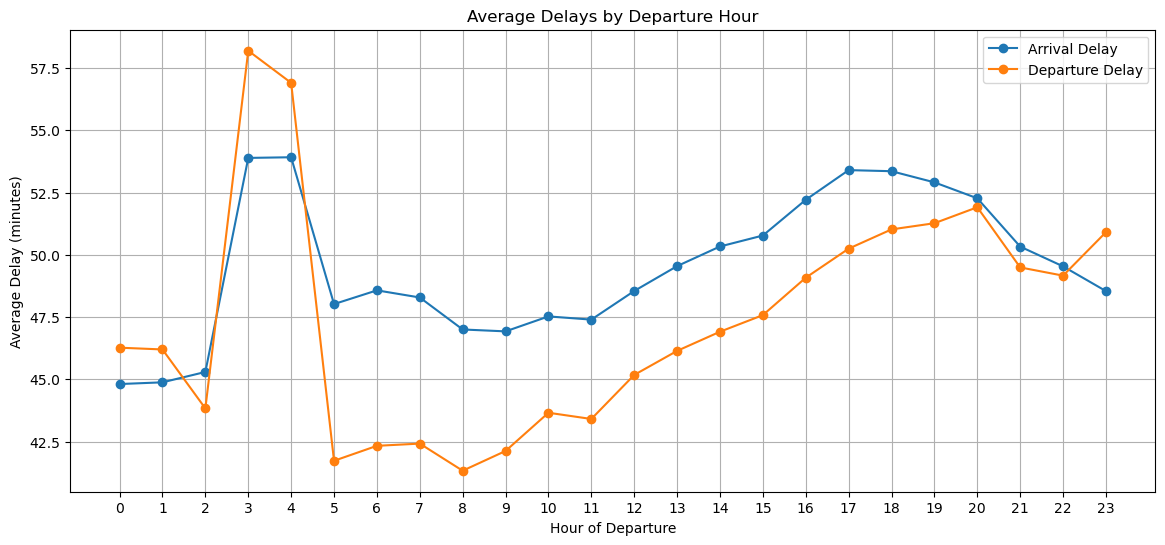

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(hour_delay['DepHour'], hour_delay['ArrDelay'], label='Arrival Delay', marker='o')
plt.plot(hour_delay['DepHour'], hour_delay['DepDelay'], label='Departure Delay', marker='o')
plt.xticks(range(0, 24))
plt.title('Average Delays by Departure Hour')
plt.xlabel('Hour of Departure')
plt.ylabel('Average Delay (minutes)')
plt.legend()
plt.grid(True)
plt.show()

## Key Insight — Average Delays by Departure Hour

- **Hour 3–4 AM** shows the highest delays (~54–58 mins) — paradoxically,
  these are not red-eye flights but cascading delays carried over from the previous day's
  disruptions that never got resolved

- **Early morning flights (5–8 AM)** have the lowest delays (~42–48 mins) —
  these depart on a "clean slate" before schedule compression builds up

- **Afternoon/Evening flights (16–20)** see a second rise in delays as small
  disruptions from earlier in the day compound across the network

- **Departure delay spikes dramatically at 3 AM** (orange line) but arrival delay
  is higher than departure delay for most of the day — meaning airlines
  are unable to recover lost time in the air

**Key Takeaway:** The best time to fly is **early morning (5–8 AM)**.
Every hour later in the day, delays accumulate due to network cascading effects.

In [45]:
filtered_df.groupby('DepHour').size()

DepHour
0       1039
1        331
2         71
3         92
4         85
5       2297
6      26129
7      34198
8      46958
9      54760
10     62389
11     70313
12     71212
13     83262
14     83303
15     84789
16     94826
17    100687
18     96942
19     92516
20     67587
21     57987
22     15489
23      5784
dtype: int64

In [46]:
# Insights:
# 1. Flight delays are generally lower during the morning hours (approximately 8–11 AM).
# 2. Both arrival and departure delays gradually increase from noon onwards, indicating delay accumulation throughout the day.
# 3. Evening flights (around 5–8 PM) experience the highest and most consistent delays.
# 4. Arrival delays are generally higher than departure delays across most hours, suggesting that airlines are often unable to fully recover lost time during transit.
# 5. Delay patterns observed during 2–4 AM should be interpreted cautiously due to the very low number of scheduled flights during those hours.

In [47]:
# Delay type breakdown
delay_cols = ['CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']
delay_means = filtered_df[delay_cols].mean()
print(delay_means)

CarrierDelay         15.105752
WeatherDelay          2.495285
NASDelay             12.229210
SecurityDelay         0.090675
LateAircraftDelay    20.514533
dtype: float64


In [48]:
# Insights:
# 1. Late-arriving aircraft is the biggest contributor to flight delays (~20.5 minutes on average).
# 2. Carrier-related operational issues (~15.1 min) and NAS delays (~12.2 min) are also major delay sources.
# 3. Weather delays contribute relatively little (~2.5 min on average).
# 4. Security-related delays are almost negligible (~0.1 min on average).
# 5. Operational factors account for a much larger share of delays than weather or security factors.

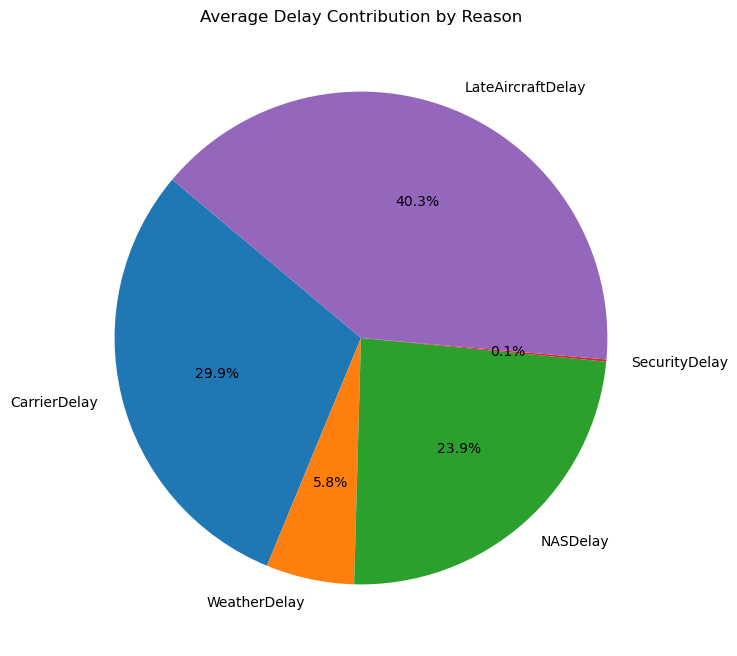

In [49]:
import matplotlib.pyplot as plt

delay_reasons = {
    'CarrierDelay': 18.73,
    'WeatherDelay': 3.63,
    'NASDelay': 14.99,
    'SecurityDelay': 0.09,
    'LateAircraftDelay': 25.25
}

plt.figure(figsize=(8,8))
plt.pie(delay_reasons.values(), labels=delay_reasons.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Average Delay Contribution by Reason')
plt.show()

## Key Insight — Average Delay Contribution by Reason

- **Late Aircraft Delay (40.3%)** is the single largest cause — meaning
  a delayed incoming aircraft causes the next flight to depart late,
  creating a domino effect across the entire network throughout the day

- **Carrier Delay (29.9%)** covers airline-controllable issues like
  crew scheduling, maintenance, and baggage handling

- Together, **Late Aircraft + Carrier Delay = 70.2%** of all delays
  are directly within airline control — confirming airlines,
  not weather or infrastructure, are the primary problem

- **NAS Delay (23.9%)** covers air traffic control and airport
  congestion — partially controllable through better scheduling

- **Weather Delay (5.8%)** and **Security Delay (0.1%)** are
  the smallest contributors and largely unavoidable

**Key Takeaway:** Over **70% of delays are airline-controllable**,
meaning systemic operational improvements by carriers could
significantly reduce the US aviation delay problem —
this is not a weather or infrastructure issue, it's an operational one.

In [50]:
# correlation between delay types
corr_cols = [
    'ArrDelay',
    'DepDelay',
    'CarrierDelay',
    'WeatherDelay',
    'NASDelay',
    'SecurityDelay',
    'LateAircraftDelay'
]

corr_matrix = filtered_df[corr_cols].corr()

print(corr_matrix)

                   ArrDelay  DepDelay  CarrierDelay  WeatherDelay  NASDelay  \
ArrDelay           1.000000  0.870109      0.297811      0.186747  0.403953   
DepDelay           0.870109  1.000000      0.339783      0.155130  0.116558   
CarrierDelay       0.297811  0.339783      1.000000     -0.116459 -0.189187   
WeatherDelay       0.186747  0.155130     -0.116459      1.000000 -0.015322   
NASDelay           0.403953  0.116558     -0.189187     -0.015322  1.000000   
SecurityDelay     -0.003496 -0.004224     -0.029608     -0.010156 -0.013642   
LateAircraftDelay  0.471232  0.533299     -0.322239     -0.097644 -0.179108   

                   SecurityDelay  LateAircraftDelay  
ArrDelay               -0.003496           0.471232  
DepDelay               -0.004224           0.533299  
CarrierDelay           -0.029608          -0.322239  
WeatherDelay           -0.010156          -0.097644  
NASDelay               -0.013642          -0.179108  
SecurityDelay           1.000000          -

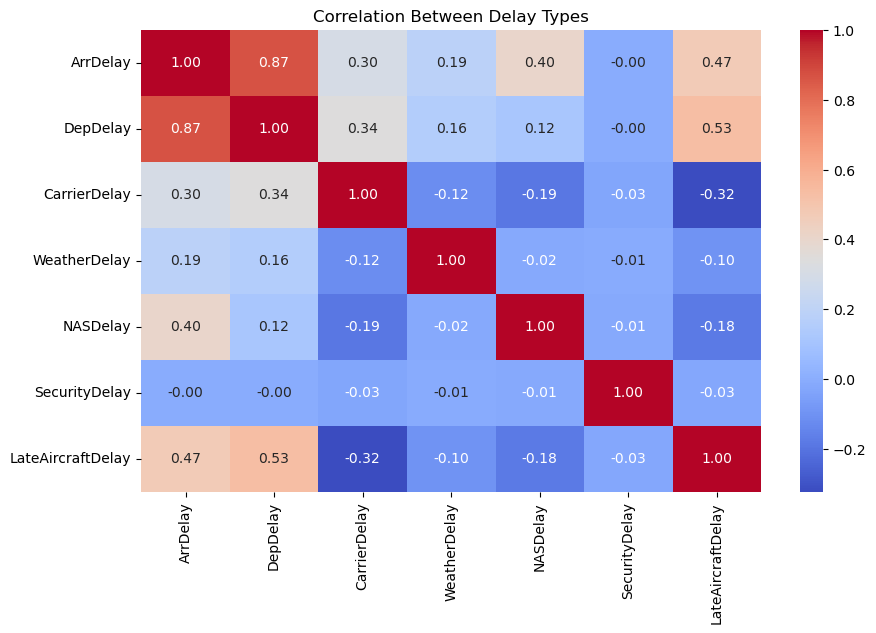

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Delay Types')
plt.show()

## Key Insight — Correlation Between Delay Types

- **ArrDelay ↔ DepDelay: 0.87** — the strongest relationship in the entire matrix.
  Flights that depart late almost always arrive late, confirming airlines
  cannot recover lost time in the air

- **LateAircraftDelay ↔ DepDelay: 0.53** — the incoming aircraft being late
  is a major driver of the next departure being delayed,
  directly proving the network cascading effect

- **CarrierDelay ↔ LateAircraftDelay: -0.32** — an interesting negative correlation.
  When carrier-caused delays are high, late aircraft delays tend to be lower,
  suggesting these two causes compete rather than compound

- **SecurityDelay: ~0.00 with everything** — security delays are completely
  independent of all other delay types, confirming they are isolated incidents

- **WeatherDelay** shows weak correlations across the board (~0.16–0.19),
  meaning weather disruptions don't systematically trigger other delay types

**Key Takeaway:** The **0.87 correlation between departure and arrival delay**
is the smoking gun — once a flight is delayed at departure,
recovery in the air is nearly impossible. The focus for improvement
must be on **preventing delays at the gate**, not recovering them in flight.

### PostgreSQL Setup

In [52]:
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")

In [53]:
# connection 
engine = create_engine(
    f"postgresql://{user}:{password}@{host}:{port}/{database}"
)
with engine.connect() as conn:
    print("Connected to PostgreSQL successfully!")

Connected to PostgreSQL successfully!


In [55]:
# Inserting the dataframe(filtered_df) in our database(flight_delays)
filtered_df.to_sql('airline_delays', engine, if_exists='replace', index=False, method='multi', chunksize=5000)

1153046